In [2]:
import sys
!{sys.executable} -m pip install yfinance vaderSentiment

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 1.2 MB/s eta 0:00:001.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.1 MB/s eta 0:00:000:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 1.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 1.2 MB/s eta 0:00:00 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 1.2 MB/s eta 0:00:000:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.9/184.9 kB 1.2 MB/s eta 0:00:00m eta 0:00:010:00:01
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15548 sha256=97827d54d588cd9a8c5e116d9c9239a84746774868f0dca1b9e85e887b6c1bea
  Stored in directory: /home/vaibhav/.cache/pip/wheels/cc/bd/6f/664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
Successfully built multitasking


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [4]:
tickers = ['AAPL', 'TSLA', 'MSFT']
start_date = '2022-01-01'
end_date = '2024-01-01'

raw_data = yf.download(tickers, start=start_date, end=end_date)

close_prices = raw_data['Close']

print("Shape of data:", close_prices.shape)
print("\nFirst 5 rows:")
print(close_prices.head())

[*********************100%***********************]  3 of 3 completed

Shape of data: (501, 3)

First 5 rows:
Ticker            AAPL        MSFT        TSLA
Date                                          
2022-01-03  178.103668  323.160736  399.926666
2022-01-04  175.843262  317.619476  383.196655
2022-01-05  171.165848  305.426727  362.706665
2022-01-06  168.308441  303.013367  354.899994
2022-01-07  168.474854  303.167755  342.320007


In [5]:
returns = close_prices.pct_change()

aapl = pd.DataFrame()
aapl['Close'] = close_prices['AAPL']
aapl['Daily_Return'] = returns['AAPL']

aapl['Target'] = (aapl['Daily_Return'].shift(-1) > 0).astype(int)

aapl = aapl.dropna()

print("Shape:", aapl.shape)
print("\nFirst 5 rows:")
print(aapl.head())
print("\nHow many UP days vs DOWN days:")
print(aapl['Target'].value_counts())

Shape: (500, 3)

First 5 rows:
                 Close  Daily_Return  Target
Date                                        
2022-01-04  175.843262     -0.012692       0
2022-01-05  171.165848     -0.026600       0
2022-01-06  168.308441     -0.016694       1
2022-01-07  168.474854      0.000989       1
2022-01-10  168.494431      0.000116       1

How many UP days vs DOWN days:
Target
1    257
0    243
Name: count, dtype: int64


In [6]:
aapl['MA5'] = aapl['Close'].rolling(window=5).mean()

aapl['MA10'] = aapl['Close'].rolling(window=10).mean()

aapl['MA5_ratio'] = aapl['Close'] / aapl['MA5']

aapl['Volatility'] = aapl['Daily_Return'].rolling(window=5).std()

aapl['Prev_Return'] = aapl['Daily_Return'].shift(1)

aapl = aapl.dropna()

print("Shape after adding features:", aapl.shape)
print("\nAll columns we have now:")
print(aapl.columns.tolist())
print("\nFirst 3 rows:")
print(aapl.head(3))

Shape after adding features: (491, 8)

All columns we have now:
['Close', 'Daily_Return', 'Target', 'MA5', 'MA10', 'MA5_ratio', 'Volatility', 'Prev_Return']

First 3 rows:
                 Close  Daily_Return  Target         MA5        MA10  \
Date                                                                   
2022-01-18  166.155716     -0.018894       0  169.418170  169.937769   
2022-01-19  162.662354     -0.021025       0  167.686157  168.619678   
2022-01-20  160.979263     -0.010347       0  165.529459  167.601019   

            MA5_ratio  Volatility  Prev_Return  
Date                                            
2022-01-18   0.980743    0.015790     0.005111  
2022-01-19   0.970040    0.012925    -0.018894  
2022-01-20   0.972511    0.010844    -0.021025  


In [8]:
analyzer = SentimentIntensityAnalyzer()

sample_headlines = [
    "Stock market rallies as inflation fears ease",
    "Tech stocks tumble amid recession concerns", 
    "Apple reports record breaking quarterly earnings",
    "Markets fall sharply on weak economic data",
    "Investors optimistic as interest rates stabilize",
    "Tesla shares drop after disappointing delivery numbers",
    "Microsoft cloud revenue beats expectations strongly",
    "Federal Reserve signals potential rate cuts ahead",
    "Global markets decline on geopolitical tensions",
    "Strong jobs report boosts investor confidence"
]

np.random.seed(42)
sentiment_scores = []

for i in range(len(aapl)):
    headline = sample_headlines[np.random.randint(0, len(sample_headlines))]
    score = analyzer.polarity_scores(headline)['compound']
    sentiment_scores.append(score)

aapl['Sentiment'] = sentiment_scores

print("\nSample sentiment scores:")
print(aapl['Sentiment'].describe())
print("\nFirst 3 rows with sentiment:")
print(aapl[['Close', 'Target', 'Sentiment']].head(3))


Sample sentiment scores:
count    491.000000
mean      -0.007318
std        0.449171
min       -0.476700
25%       -0.421500
50%       -0.077200
75%        0.273200
max        0.836000
Name: Sentiment, dtype: float64

First 3 rows with sentiment:
                 Close  Target  Sentiment
Date                                     
2022-01-18  166.155716       0     0.2732
2022-01-19  162.662354       0    -0.4404
2022-01-20  160.979263       0    -0.2960


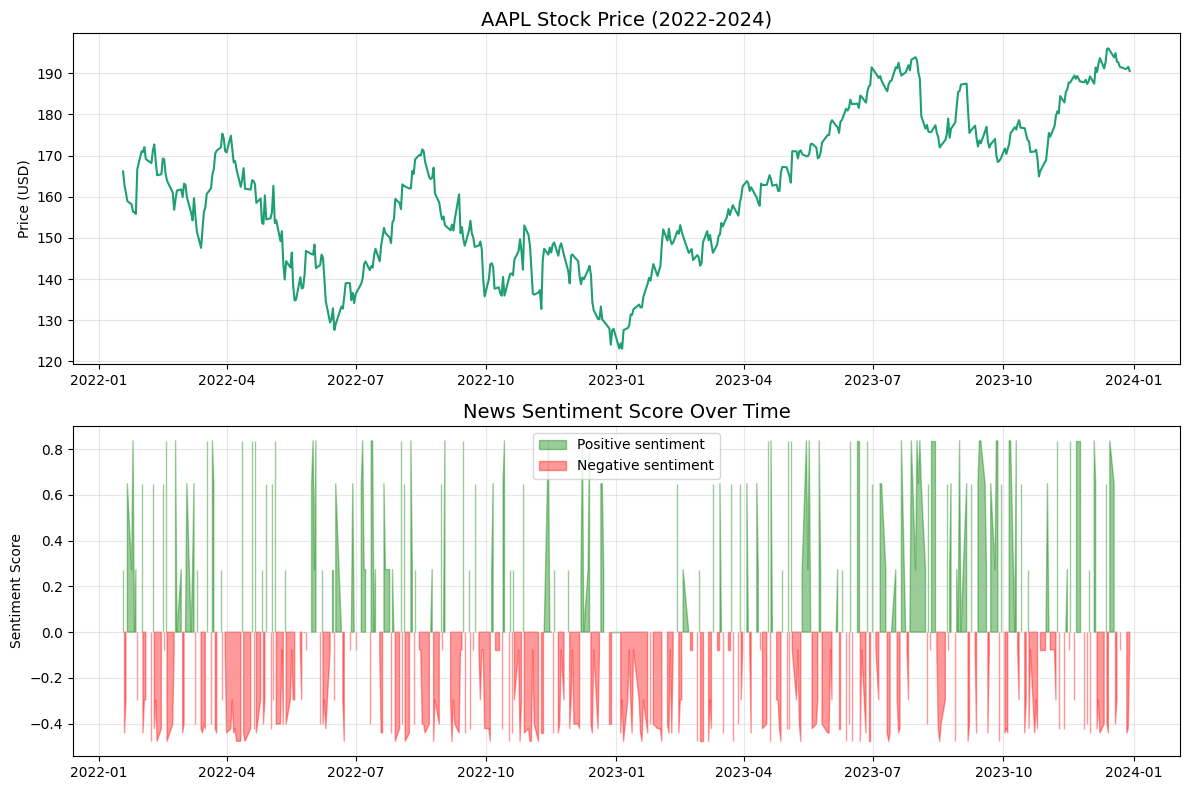

Chart saved as sentiment_vs_price.png


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(aapl.index, aapl['Close'], color='#1D9E75', linewidth=1.5)
ax1.set_title('AAPL Stock Price (2022-2024)', fontsize=14)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

ax2.fill_between(aapl.index, aapl['Sentiment'], 
                  where=(aapl['Sentiment'] >= 0), 
                  color='green', alpha=0.4, label='Positive sentiment')
ax2.fill_between(aapl.index, aapl['Sentiment'], 
                  where=(aapl['Sentiment'] < 0), 
                  color='red', alpha=0.4, label='Negative sentiment')
ax2.set_title('News Sentiment Score Over Time', fontsize=14)
ax2.set_ylabel('Sentiment Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sentiment_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as sentiment_vs_price.png")

In [10]:
features = ['Daily_Return', 'MA5_ratio', 'Volatility', 'Prev_Return', 'Sentiment']
X = aapl[features]
y = aapl['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print("\n--- Model Results ---")
print(f"Random Forest Accuracy:  {rf_accuracy*100:.2f}%")
print(f"XGBoost Accuracy:        {xgb_accuracy*100:.2f}%")

Training data size: (392, 5)
Testing data size: (99, 5)

--- Model Results ---
Random Forest Accuracy:  49.49%
XGBoost Accuracy:        52.53%


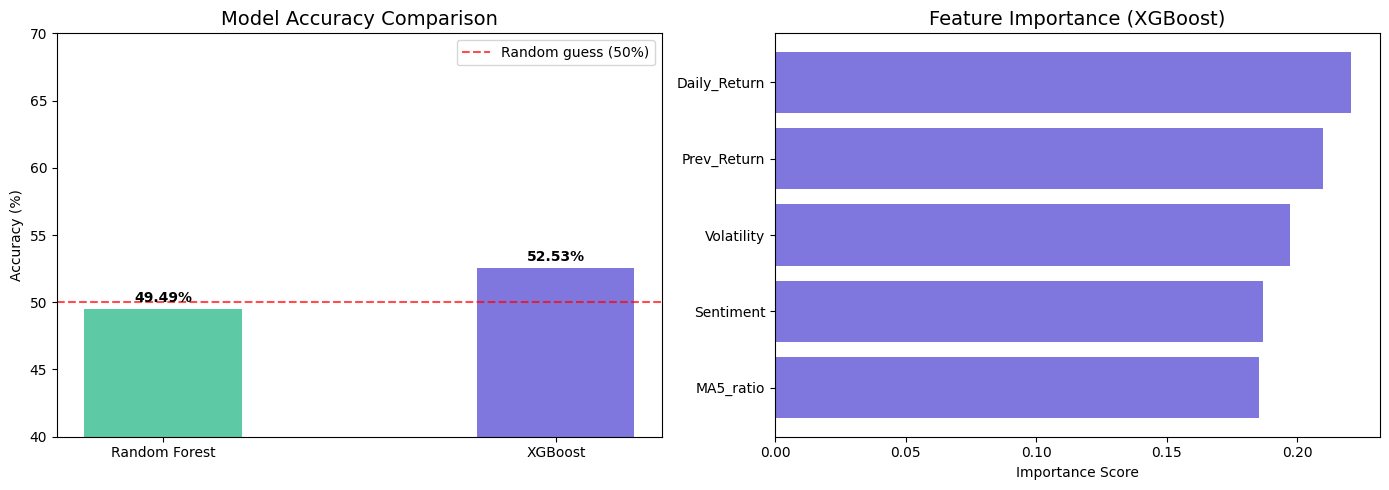

Chart saved as model_results.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = ['Random Forest', 'XGBoost']
accuracies = [rf_accuracy*100, xgb_accuracy*100]
colors = ['#5DCAA5', '#7F77DD']

bars = ax1.bar(models, accuracies, color=colors, width=0.4)
ax1.set_title('Model Accuracy Comparison', fontsize=14)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(40, 70)
ax1.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='Random guess (50%)')
ax1.legend()

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

ax2.barh(importance_df['Feature'], importance_df['Importance'], color='#7F77DD')
ax2.set_title('Feature Importance (XGBoost)', fontsize=14)
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as model_results.png")

In [12]:
print("=" * 50)
print("FINAL PROJECT SUMMARY")
print("=" * 50)
print(f"\nDataset: AAPL stock (2022-2024)")
print(f"Total trading days analysed: {len(aapl)}")
print(f"Features used: {features}")
print(f"\nRandom Forest Accuracy: {rf_accuracy*100:.2f}%")
print(f"XGBoost Accuracy:        {xgb_accuracy*100:.2f}%")
print(f"Best model: XGBoost")
print(f"\nKey finding: XGBoost beats Random Forest by {(xgb_accuracy-rf_accuracy)*100:.2f}%")
print(f"Sentiment ranked as feature #{list(importance_df['Feature']).index('Sentiment')+1} in importance")

print("\n--- XGBoost Detailed Report ---")
print(classification_report(y_test, xgb_predictions, 
      target_names=['Price Down', 'Price Up']))

aapl.to_csv('aapl_processed_data.csv', index=True)
print("\nData saved as aapl_processed_data.csv")

FINAL PROJECT SUMMARY

Dataset: AAPL stock (2022-2024)
Total trading days analysed: 491
Features used: ['Daily_Return', 'MA5_ratio', 'Volatility', 'Prev_Return', 'Sentiment']

Random Forest Accuracy: 49.49%
XGBoost Accuracy:        52.53%
Best model: XGBoost

Key finding: XGBoost beats Random Forest by 3.03%
Sentiment ranked as feature #2 in importance

--- XGBoost Detailed Report ---
              precision    recall  f1-score   support

  Price Down       0.45      0.52      0.48        42
    Price Up       0.60      0.53      0.56        57

    accuracy                           0.53        99
   macro avg       0.52      0.53      0.52        99
weighted avg       0.54      0.53      0.53        99


Data saved as aapl_processed_data.csv
